## Setup

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

from src.calculate_similarity import calculate_similarity
from src.embed import embed
from src.gen_functions.gen_dumbbell import generate_dumbbell_pointcloud
from src.gen_functions.gen_helix import generate_toroidal_helix_pointcloud
from src.gen_functions.gen_torus import generate_torus_pointcloud
from src.graph.create_graph import pointcloud_to_graph
from src.graph.highlight_diffusion_paths import diffusion_paths
from src.kernels import gaussian_full_similarity
from src.plot.visualise_dumbbell import vis_diffusion_graph, vis_dumbbell
from src.plot.visualise_embedding import vis_embedding
from src.plot.visualise_pointcloud import vis_pointcloud
from src.transformations import rotate_pointcloud, shift_pointcloud

## Dumbbell

Example for 3.1.1 Dumbbell-shaped dataset

In [ ]:
"""Generate the dumbbell point cloud data."""

X_db, labels = generate_dumbbell_pointcloud(
    n_left=250,
    n_right=250,
    n_bridge=15,
    cluster_radius=1.0,
    bridge_half_width=0.01,
    noise=0.015,
    seed=2,
)

print("X_db shape:", X_db.shape)

X_db shape: (515, 2)


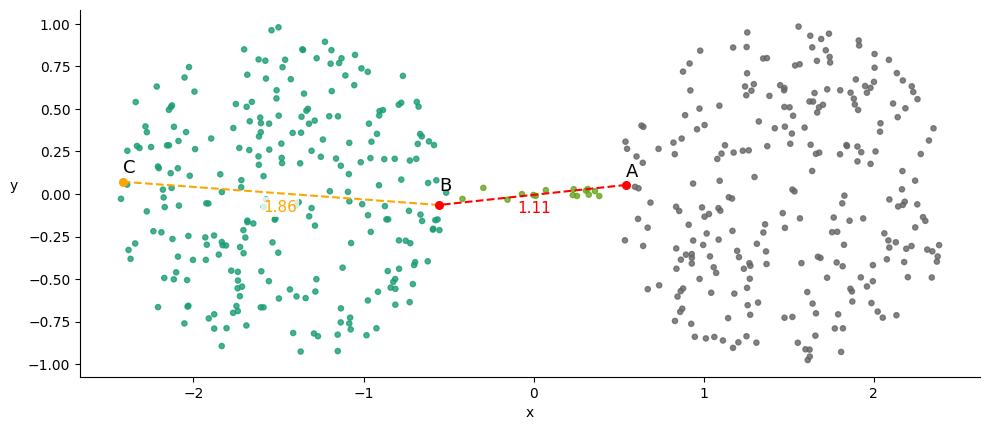

In [ ]:
"""Visualising the dumbbell point cloud with Euclidean distance."""

vis_dumbbell(X=X_db, labels=labels, points=[401, 222, 199], euclidean=True)

In [ ]:
"""Calculating the Gaussian similarity matrix for the point cloud data."""

W = gaussian_full_similarity(X=X_db, epsilon=0.05)

In [ ]:
"""Embedding the graph using the diffusion maps algorithm."""

Psi, evals, M = embed(W=W, t=1, Markov=True, right_evec=False)

In [ ]:
"""Constructing the graph from the point cloud data."""

G = pointcloud_to_graph(X_db, M, labels)

In [ ]:
"""Calculating diffusion paths between specific nodes in the graph."""

G_dif = diffusion_paths(
    G, start_node=401, end_node=222, n_paths=2500, max_steps=45, color="red"
)

G_dif = diffusion_paths(
    G, start_node=199, end_node=222, n_paths=2500, max_steps=45, color="orange"
)

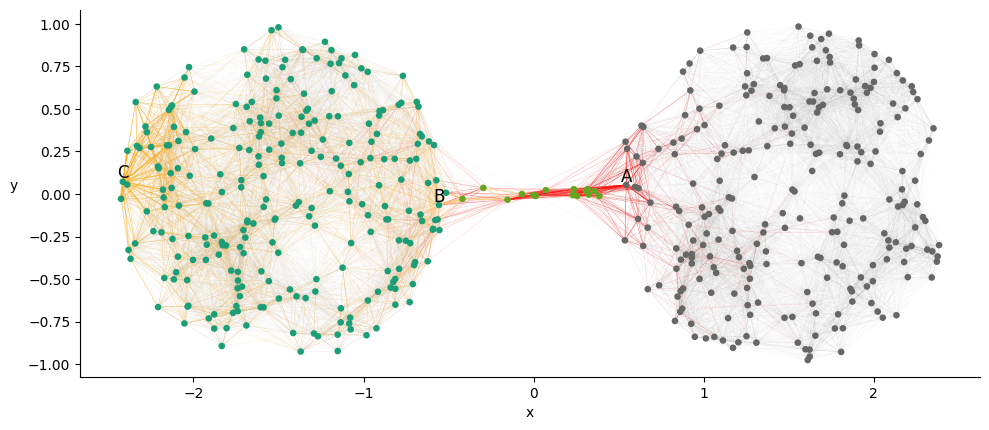

In [ ]:
"""Visualising the diffusion paths on the graph."""

highlights = {401: ("A", "black"), 222: ("B", "black"), 199: ("C", "black")}

vis_diffusion_graph(G_dif, nodes_to_label=highlights)

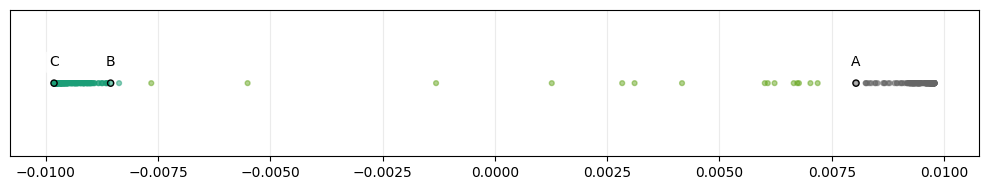

In [ ]:
"""Visualising the 1D embedding of the dumbbell with highlighted points."""

vis_embedding(
    Psi=Psi,
    dim=1,
    labels=labels,
    highlight=True,
    points=[
        {"index": 401, "label": "A"},
        {"index": 222, "label": "B"},
        {"index": 199, "label": "C"},
    ],
    cmap="Dark2",
)

## Helix

Example for 3.1.2 Toroidal helix shaped dataset

In [ ]:
"""Generating the helix point cloud data."""

X_h, c_h = generate_toroidal_helix_pointcloud(
    num_points=3000,
    R=2.5,
    r=1.0,
    k=6,
    turns=1.0,
    noise=0.03,
    seed=42,
)

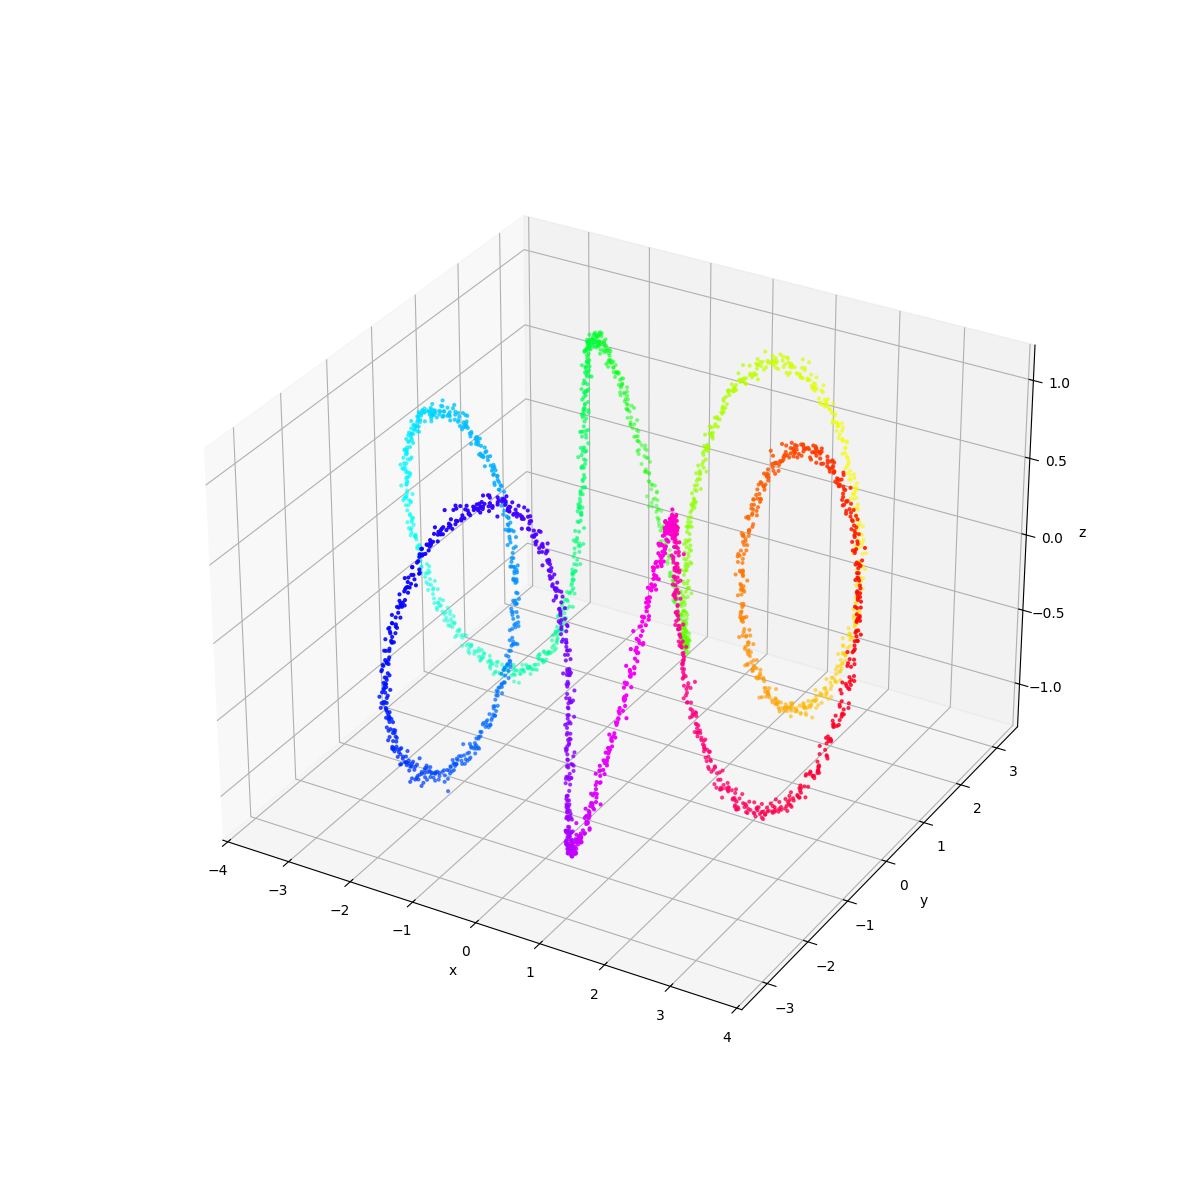

In [ ]:
"""Visualising the helix point cloud data."""

vis_pointcloud(X=X_h, c=c_h, figsize=(12, 12), axis=True, cmap="hsv")

In [ ]:
"""Calculating the Gaussian similarity matrix for the point cloud data."""

W_h = gaussian_full_similarity(X=X_h, epsilon=0.05)

In [ ]:
"""Embedding the graph using the diffusion maps algorithm."""

Psi_h, evals_h = embed(W=W_h, t=1, Markov=False, right_evec=False)

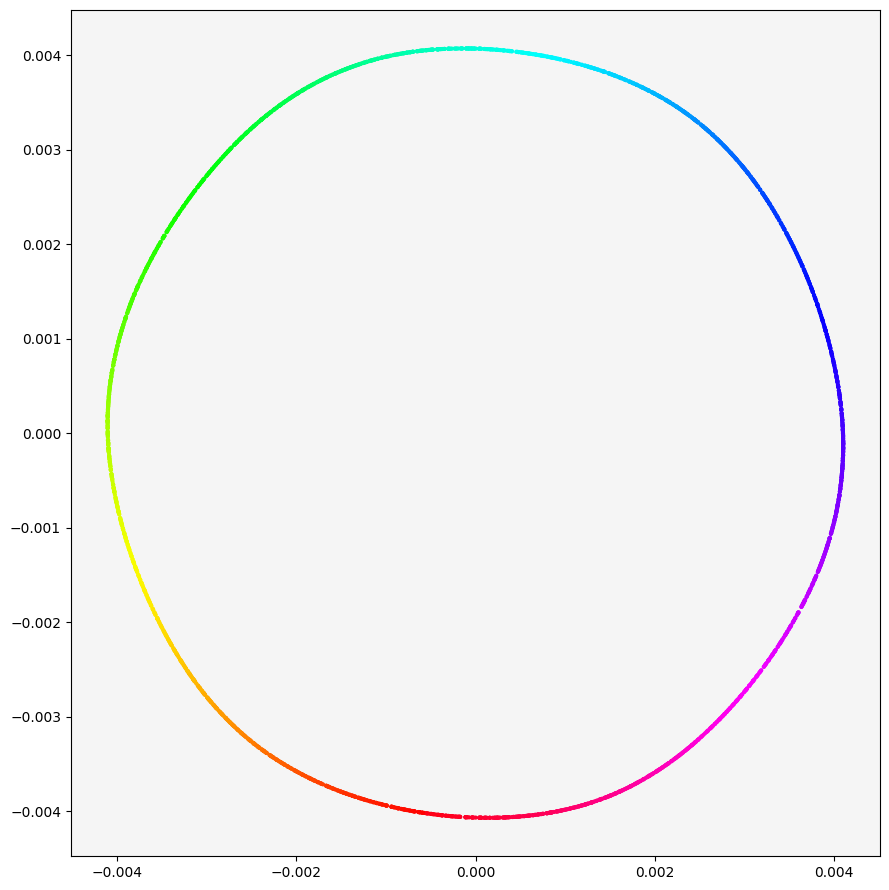

In [ ]:
"""Visualising the 2D embedding of the helix."""

vis_embedding(Psi=Psi_h, dim=2, labels=c_h, highlight=False, points=None, cmap="hsv")

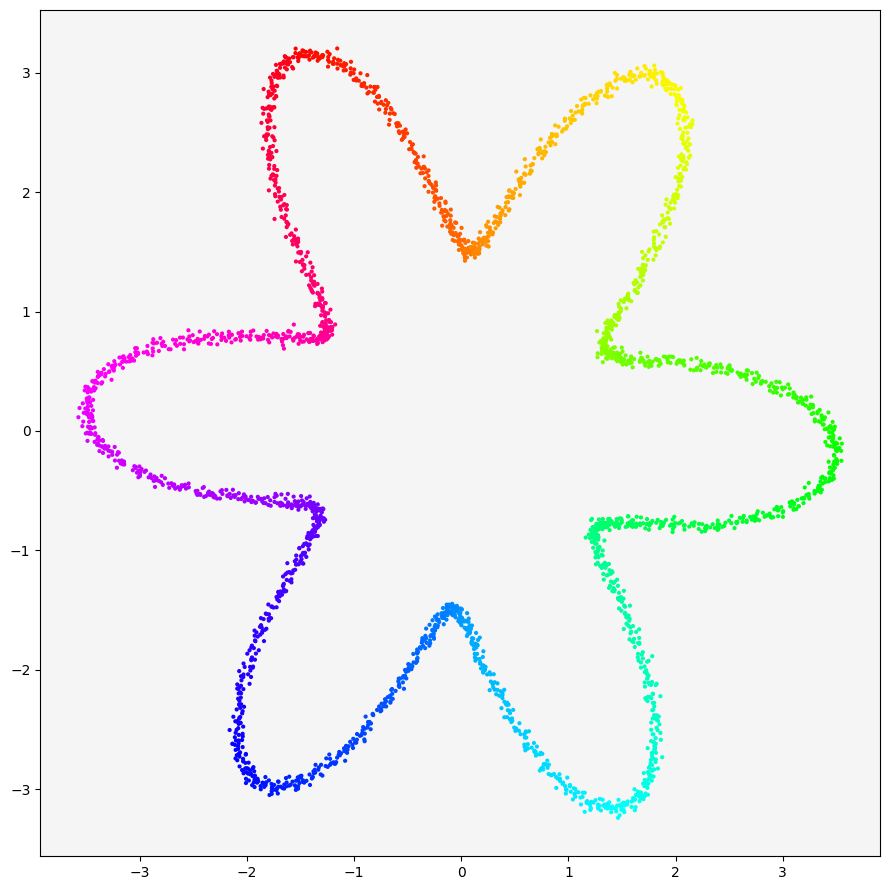

In [ ]:
"""PCA on the helix."""

# Fit PCA and transform to 2D
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_h)

vis_embedding(Psi=Z_pca, dim=2, labels=c_h, highlight=False, points=None, cmap="hsv")

## Torus

Example for subsection 3.1.3 Torus-shaped dataset.

In [ ]:
"""Generating the point cloud data in the shape of a torus."""

X, u = generate_torus_pointcloud(n=5000, R=3.0, r=1.0, noise=0.02, seed=2)

In [ ]:
"""Generating a shifted and rotated copy of the torus."""

Y = X.copy()

# defining the shift vector
shift_vector = np.array([100.0, 100.0, 100.0])

Y = shift_pointcloud(X=Y, shift_vector=shift_vector)

# defining the rotaiton matrix around x-axis by 90 degrees
theta = np.pi / 2
R_x = np.array(
    [[1, 0, 0], [0, np.cos(theta), -np.sin(theta)], [0, np.sin(theta), np.cos(theta)]]
)

Y = rotate_pointcloud(X=Y, rotation_matrix=R_x)

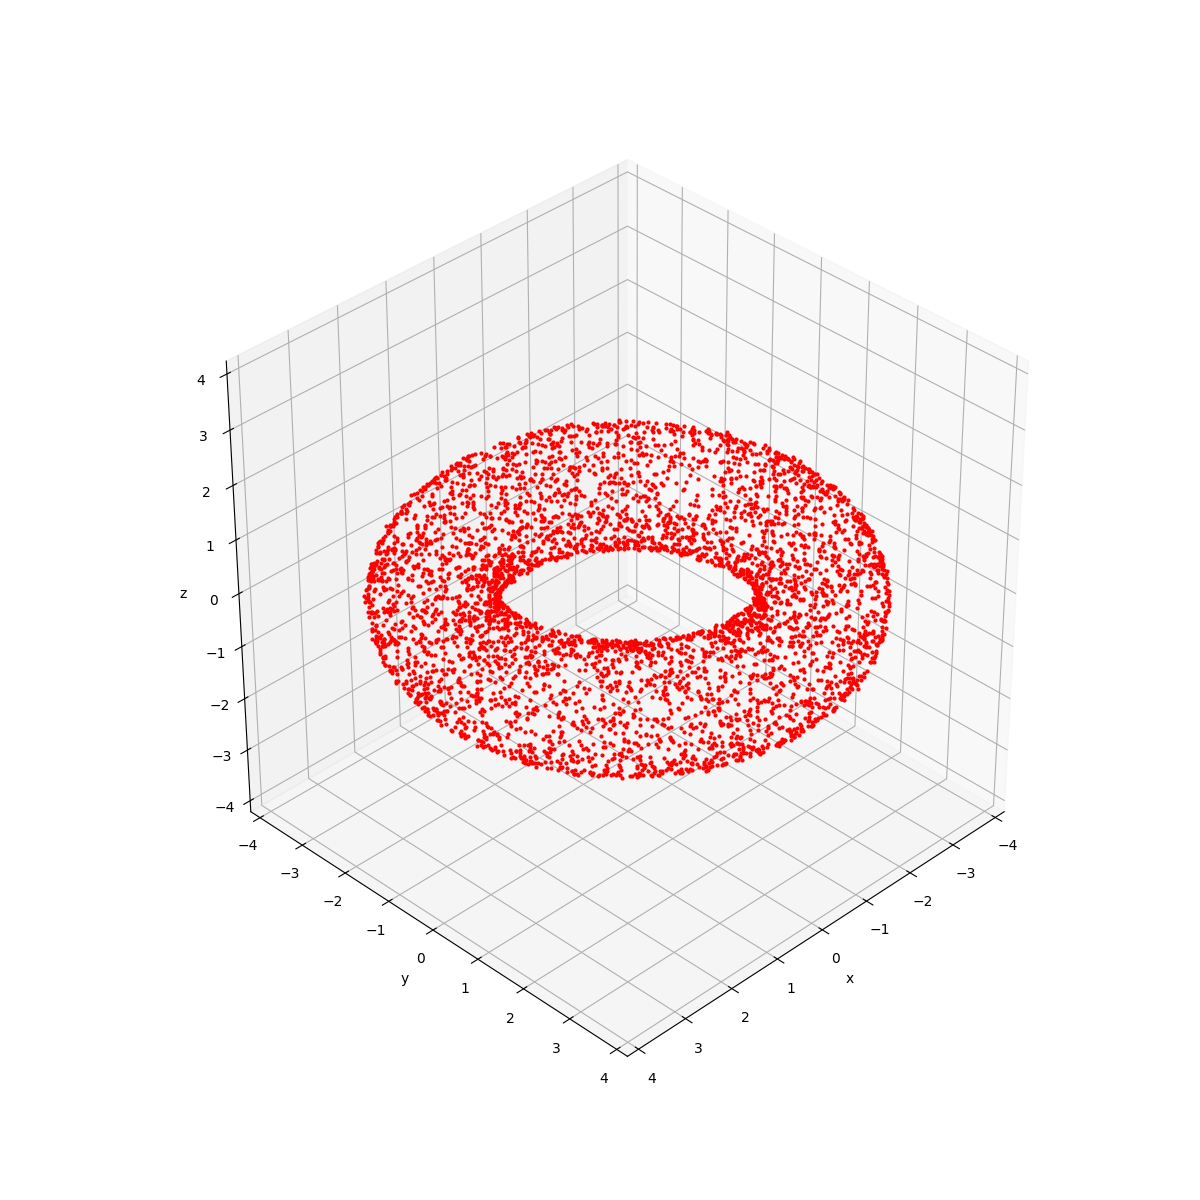

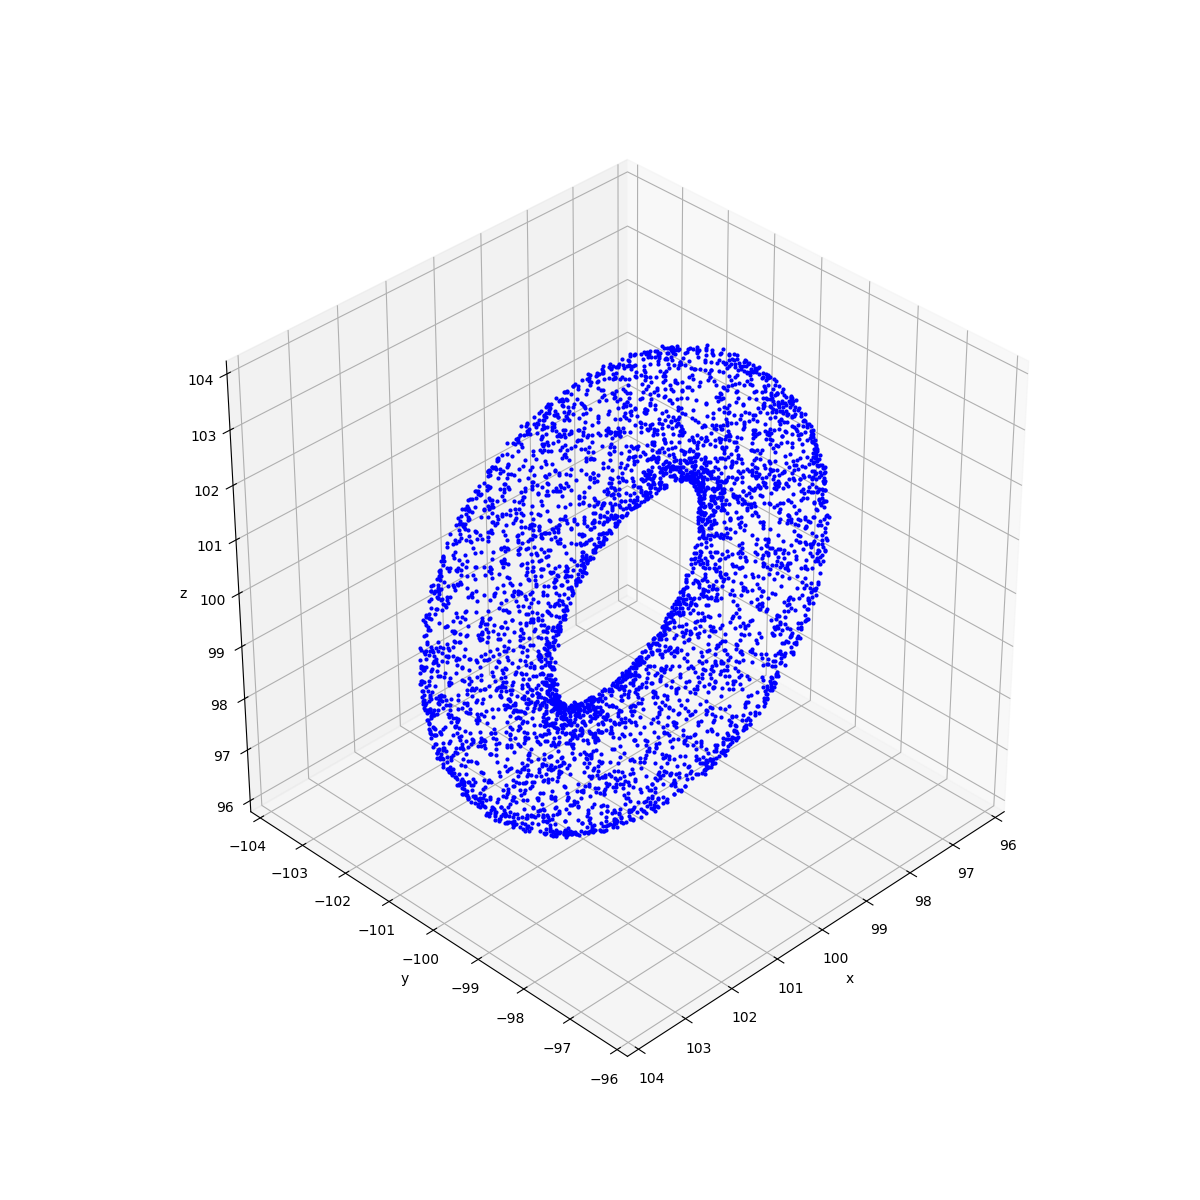

In [ ]:
"""Visualising point cloud data in the shape of a tori."""

vis_pointcloud(
    X=X,
    color="red",
    figsize=(12, 12),
    elev=35,
    azim=45,
    depthshade=False,
    equal_aspect=True,
    axis=True,
)

vis_pointcloud(
    X=Y,
    color="blue",
    figsize=(12, 12),
    elev=35,
    azim=45,
    depthshade=False,
    equal_aspect=True,
    axis=True,
)

In [ ]:
"""Calculating the Gaussian similarity matrix for the point cloud data."""

W_torus_or = gaussian_full_similarity(X=X, epsilon=0.05)
W_torus_tr = gaussian_full_similarity(X=Y, epsilon=0.05)

In [ ]:
"""Embedding the original and transformed torus point clouds together."""

Psi_torus_or, evals_torus_or = embed(W=W_torus_or, t=1, Markov=False, right_evec=False)
Psi_torus_tr, evals_torus_tr = embed(W=W_torus_tr, t=1, Markov=False, right_evec=False)

In [ ]:
signs = np.sign(np.sum(Psi_torus_or * Psi_torus_tr, axis=0))
signs[signs == 0] = 1.0
Psi_torus_tr_al = Psi_torus_tr * signs[None, :]

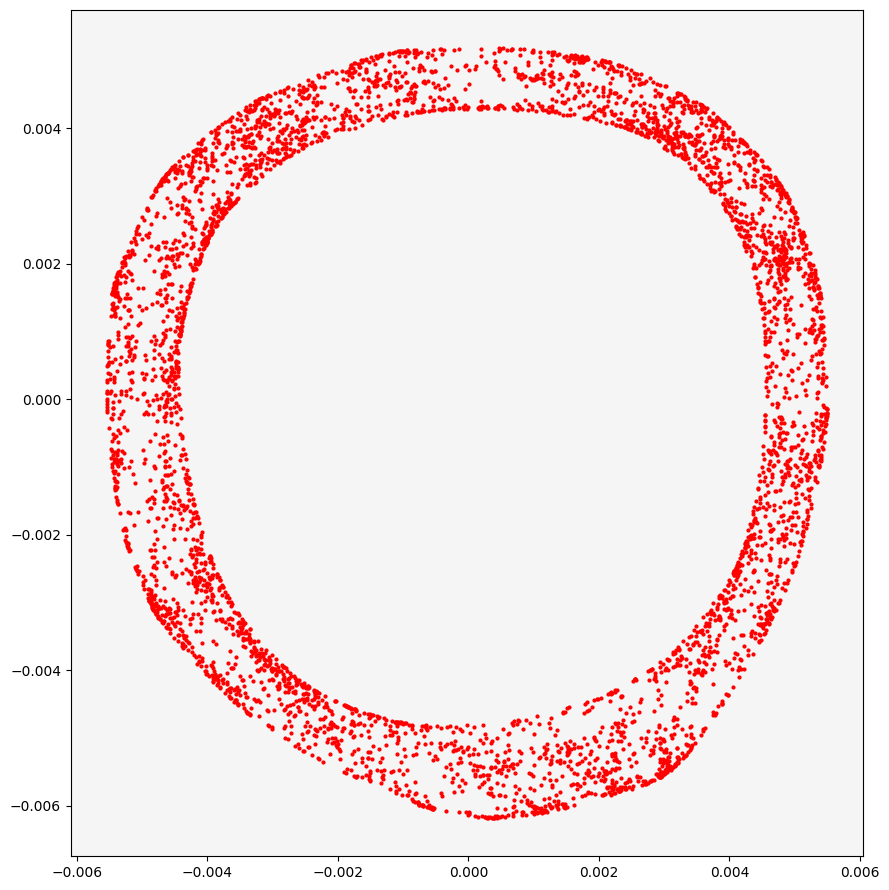

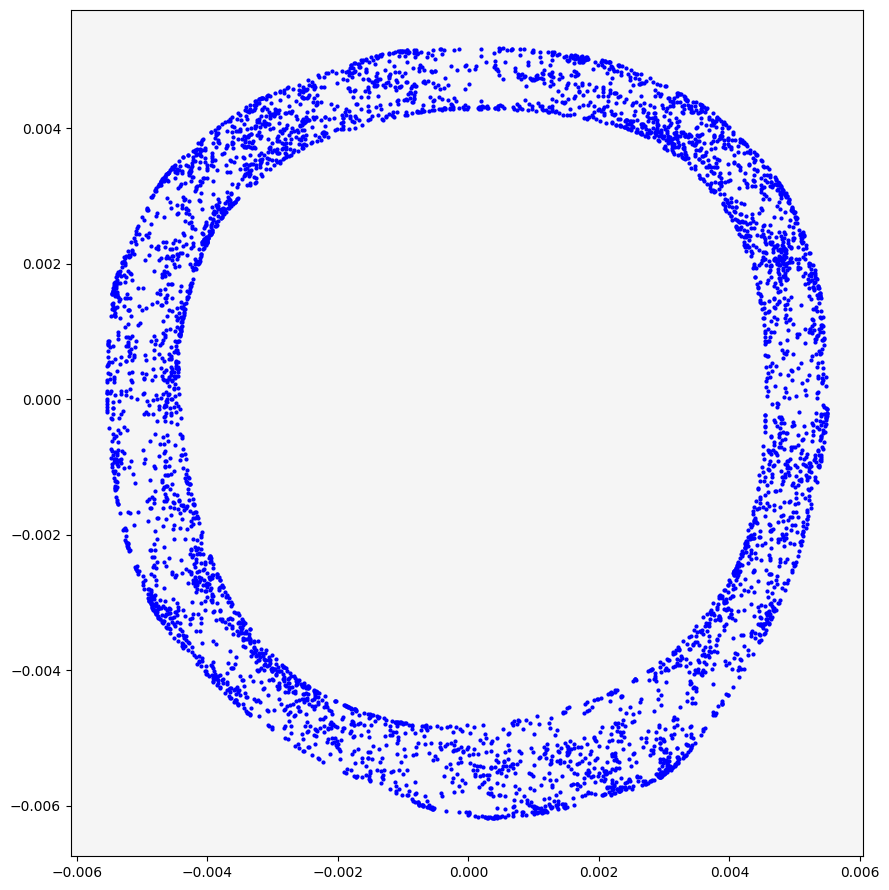

In [ ]:
"""Visualising the 2D embedding of the original and transformed torus point clouds."""

vis_embedding(
    Psi=Psi_torus_or,
    dim=2,
    labels=u,
    highlight=False,
    points=None,
    cmap=None,
    color="red",
)

vis_embedding(
    Psi=Psi_torus_tr_al,
    dim=2,
    labels=u,
    highlight=False,
    points=None,
    cmap=None,
    color="blue",
)

In [ ]:
"""Similrity between original datasets + original vs shifted forward."""

# X vs Y
print(f"Absolute error between V1, V2: {calculate_similarity(X, Y)}")


# V1_embedded vs V2_embedded
print(
    f"Absolute error between V1_embedded, V2_embedded: {calculate_similarity(Psi_torus_or, Psi_torus_tr_al)}"
)

Absolute error between V1, V2: 866216.9660250349
Absolute error between V1_embedded, V2_embedded: 3.611938573837237e-07
